In [1]:
import warnings

import janitor
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from utilities.graph_utils import save_mpl_fig
from utilities.utils import get_fulldata, pandas_to_tex, process_land_area

warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", font_scale=1.5, style="whitegrid")

FP_LLM = "../data/llm_names_sex_religion.parquet"

/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:92: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:92: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packa

In [2]:
usecols = ["account_no", "name_of_ryot", "6", "7", "8"]
df = (
    get_fulldata(usecols=usecols, low_memory=False)
    .pipe(process_land_area)
    .merge(
        (
            pd.read_parquet(
                FP_LLM,
                columns=["name", "entity_type", "gender", "prop_women"],
            )
            .query("entity_type=='human'")
            .remove_columns("entity_type")
            .drop_duplicates("name")
            .rename_column("name", "name_of_ryot")
            .query("gender != 'cannot_decide'")
        ),
        how="inner",
        on="name_of_ryot",
        validate="m:1",
    )
    .assign(gender=lambda df_: df_["gender"].map({"woman": "female", "man": "male"}))
)
df.info()
print(f"{df['account_no'].nunique()=}")
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35712976 entries, 0 to 35712975
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   name_of_ryot  object 
 1   account_no    int64  
 2   acres         float64
 3   decimals      float64
 4   hectare       float64
 5   tt_area_acre  float64
 6   gender        object 
 7   prop_women    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.1+ GB
df['account_no'].nunique()=11514099


,name_of_ryot,account_no,acres,decimals,hectare,tt_area_acre,gender,prop_women
0,कपिलदेव पाठक,1801010001000002,0.0,66.0,0.0,0.66,male,0.01
1,कपिलदेव पाठक,1801010001000002,0.0,8.0,0.0,0.08,male,0.01
2,कपिलदेव पाठक,1801010001000002,0.0,6.0,0.0,0.06,male,0.01


In [4]:
df["name_of_ryot"].nunique()

3075825

In [5]:
df["account_no"].nunique()

11514099

## Summary numbers

In [6]:
n_land_woman = len(df.query("gender=='female'"))
perc_land_woman = 100 * n_land_woman / len(df)

print(f"{n_land_woman:,.0f} ({perc_land_woman:.1f}%) land plots are owned by woman")

4,069,622 (11.4%) land plots are owned by woman


In [7]:
df_num_plots = (
    df.groupby(["account_no", "gender"])
    .size()
    .reset_index()
    .rename_column(0, "nplots")
)
df_num_plots.head(3)

,account_no,gender,nplots
0,101010273000001,male,2
1,101010273000002,male,8
2,101010273000003,male,1


In [8]:
n_accounts_woman = len(df_num_plots.query("gender=='female'"))
perc_accounts_woman = 100 * n_accounts_woman / len(df_num_plots)

print(f"{n_accounts_woman:,.0f} ({perc_accounts_woman:.1f}%) accounts are under woman")

1,829,754 (15.9%) accounts are under woman


## Tabulate overall shares by gender

In [9]:
_x = "tt_area_acre"
df_landshares = (
    df.groupby(["gender"])[_x].sum().reset_index()
    .assign(landshare=lambda df_: 100 * (df_[_x] / df_[_x].sum()))
    .rename_column(_x, "land")
)
rounding_error = 0.01
assert rounding_error > (100 - df_landshares["landshare"].sum())
df_landshares

,gender,land,landshare
0,female,2.626107e+06,8.834626
1,male,2.709906e+07,91.165374


In [10]:
_x = "nplots"
df_plotshares = (
    df_num_plots.groupby(["gender"])[_x].sum().reset_index()
    .assign(plotshare=lambda df_: 100 * (df_[_x] / df_[_x].sum()))
    .rename_column(_x, "plots")
)
assert df_plotshares["plotshare"].sum() == 100
df_plotshares

,gender,plots,plotshare
0,female,4069622,11.395359
1,male,31643354,88.604641


In [11]:
df_shares = (
    df_plotshares.merge(df_landshares, on=["gender"], how="left", validate="1:1")
    .sort_values("landshare", ascending=False, ignore_index=True)
    .assign(landshare_cs=lambda df_: df_["landshare"].cumsum())
    .assign(plotshare_cs=lambda df_: df_["plotshare"].cumsum())
    .reorder_columns(["gender", "plots", "plotshare", "plotshare_cs"])
    # see 01_secc_gender_caste_proportions.ipynb
    .assign(base_adultpop=[52.316132609637044, 47.683867390362984])
    .assign(gender=["Men", "Women"])
)
pandas_to_tex(df_shares, "../tables/landshares_by_gender_llm", float_format="%.2f")
df_shares

,gender,plots,plotshare,plotshare_cs,land,landshare,landshare_cs,base_adultpop
0,Men,31643354,88.604641,88.604641,2.709906e+07,91.165374,91.165374,52.316133
1,Women,4069622,11.395359,100.000000,2.626107e+06,8.834626,100.000000,47.683867


### Number of plots per account, by gender

In [12]:
ntiles = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1]
tab_nplot_perc_men = (
    df_num_plots.query("gender=='male'")
    .nplots.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("nplots", "nplots_men")
    .astype({"nplots_men": int})
)
tab_nplot_perc_women = (
    df_num_plots.query("gender=='female'")
    .nplots.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("nplots", "nplots_women")
    .astype({"nplots_women": int})
)
tab_nplot_perc = (
    tab_nplot_perc_women
    .merge(tab_nplot_perc_men, on="Percentile", how="left", validate="1:1")
    .assign(
        nplots_women=lambda df: df.nplots_women.map("{:,.0f}".format),
        nplots_men=lambda df: df.nplots_men.map("{:,.0f}".format),
    )
)
pandas_to_tex(
    tab_nplot_perc,
    "../tables/percentiles_landplots_per_accountholder_gender_llm",
    float_format="%.2f",
)
tab_nplot_perc

,Percentile,nplots_women,nplots_men
0,0.00,1,1
1,0.10,1,1
2,0.20,1,1
3,0.30,1,1
4,0.40,1,1
5,0.50,1,1
6,0.60,1,1
7,0.70,2,2
8,0.80,2,3
9,0.90,4,7


In [13]:
LINESTYLES = ["-", "--"]
DISPLOT_OPTS = dict(
    aspect=1.5,
    height=6,
    hue="gender",
    legend=False,
    palette="cividis",
    linewidth=2.5,
)
HISTDENSITY_OPTS = dict(
    hue="gender",
    legend=False,
    palette="cividis",
)

LEGEND_OPTS = {
    "title": "",
    "loc": "best",
    "labels": ["Male", "Female"],
    "frameon": False,
    "fontsize": 24,
    "handletextpad": 0.3,
}

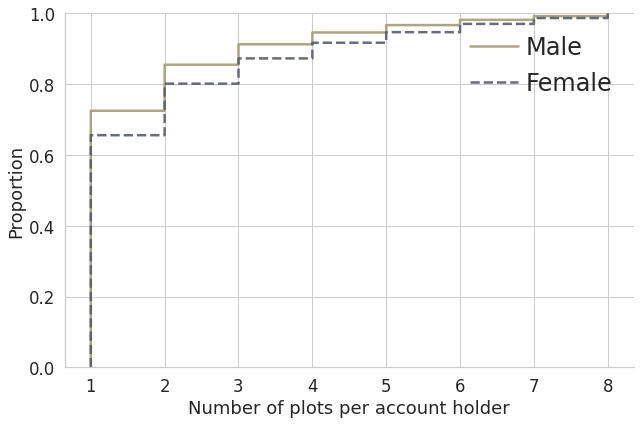

In [14]:
_n = 8

g = sns.displot(
    x="nplots",
    data=df_num_plots.query(f"nplots<={_n}"),
    alpha=0.9,
    kind="ecdf",
    **DISPLOT_OPTS,
)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)
plt.xlabel("Number of plots per account holder")
save_mpl_fig("../figures/number_plots_per_accountholder_ecdf_gender_llm")

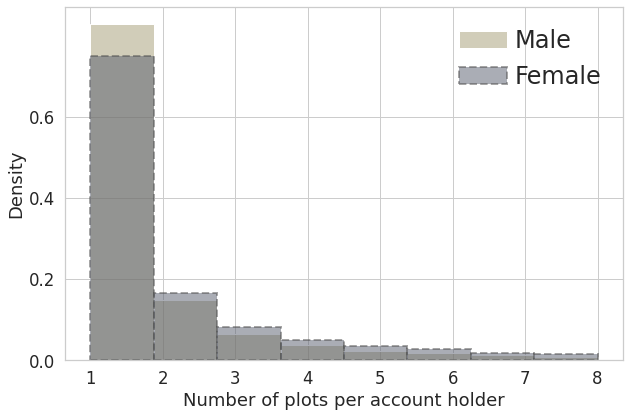

In [15]:
_, ax = plt.subplots(figsize=(10, 6.5))
sns.histplot(
    data=df_num_plots.query(f"nplots<={_n}"),
    x="nplots",
    bins=_n,
    stat="density",
    common_norm=False,
    **HISTDENSITY_OPTS,
    alpha=0.5,
    ax=ax,
)
plt.xlabel("Number of plots per account holder")
plt.yticks([0, 0.2, 0.4, 0.6])

bars = ax.containers[1].get_children()
for bar in bars:
    bar.set_linestyle("--")
    bar.set_linewidth(2)
    bar.set_edgecolor("0.3")
    bar.set_alpha(0.5)
plt.legend(**LEGEND_OPTS)
save_mpl_fig("../figures/number_plots_per_accountholder_histogram_gender_llm")

### Land area per account, by gender

In [16]:
df_landarea = (
    df.groupby(["account_no", "gender"])["tt_area_acre"]
    .sum()
    .reset_index()
)
df_landarea.head(3)

,account_no,gender,tt_area_acre
0,101010273000001,male,0.585
1,101010273000002,male,1.545
2,101010273000003,male,0.080


In [17]:
ntiles = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1]
tab_area_perc_men = (
    df_landarea.query("gender=='male'")
    .tt_area_acre.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("tt_area_acre", "area_men")
)
tab_area_perc_women = (
    df_landarea.query("gender=='female'")
    .tt_area_acre.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("tt_area_acre", "area_women")
)
tab_area_perc = (
    tab_area_perc_women
    .merge(tab_area_perc_men, on="Percentile", how="left", validate="1:1")
    .assign(
        area_women=lambda df: df.area_women.map("{:,.2f}".format),
        area_men=lambda df: df.area_men.map("{:,.2f}".format),
    )
)
pandas_to_tex(
    tab_area_perc,
    "../tables/percentiles_landarea_per_accountholder_gender_llm",
    float_format="%.2f",
)
tab_area_perc

,Percentile,area_women,area_men
0,0.00,0.00,0.00
1,0.10,0.03,0.04
2,0.20,0.05,0.08
3,0.30,0.10,0.14
4,0.40,0.16,0.22
5,0.50,0.24,0.34
6,0.60,0.36,0.51
7,0.70,0.54,0.78
8,0.80,0.86,1.26
9,0.90,1.62,2.50


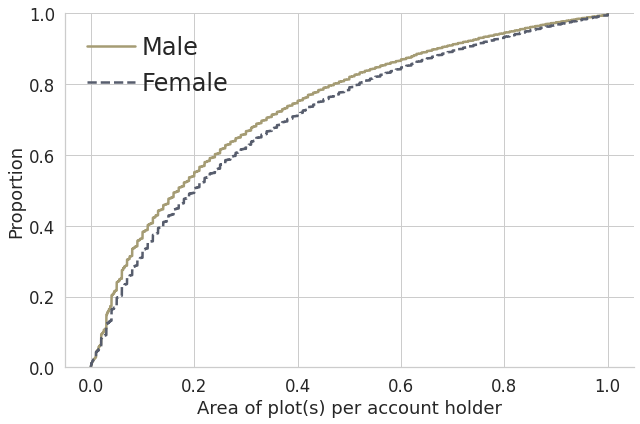

In [18]:
_area = 1

g = sns.displot(
    x="tt_area_acre",
    data=df_landarea.query(f"tt_area_acre<={_area}"),
    kind="ecdf",
    **DISPLOT_OPTS,
)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)
plt.xlabel("Area of plot(s) per account holder")
save_mpl_fig("../figures/plot_area_per_accountholder_ecdf_gender_llm")

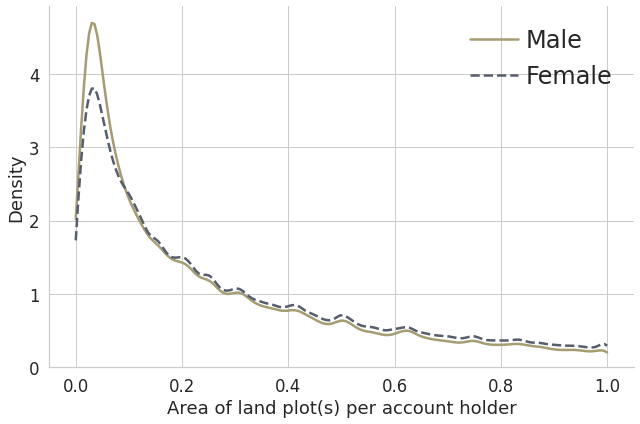

In [19]:
g = sns.displot(
    data=df_landarea.query(f"tt_area_acre<={_area}"),
    x="tt_area_acre",
    kind="kde",
    common_norm=False,
    **DISPLOT_OPTS,
    cut=0,
)
g.set_xlabels("Area of land plot(s) per account holder")
plt.locator_params(axis="y", nbins=5)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)